# Análisis de Sentimientos
Este cuaderno realiza un análisis de sentimientos sobre un conjunto de comentarios utilizando modelos pre-entrenados de Hugging Face.

In [2]:
from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del modelo (basado en el original)
classifier = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

c:\Users\lemus\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\lemus\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lemus\.cache\huggingface\hub\models--nlptown--bert-base-multilingual-uncased-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mod

In [3]:
# Conjunto de comentarios para analizar
comentarios = [
    "El producto es excelente, superó mis expectativas.",
    "No me gustó para nada, llegó roto y tarde.",
    "Es un término medio, cumple su función pero podría ser mejor.",
    "Increíble atención al cliente, muy amables.",
    "Pésima experiencia, no volvería a comprar aquí.",
    "Me encanta el diseño, es muy moderno.",
    "El precio es algo elevado para la calidad que ofrece.",
    "Funciona perfectamente, muy fácil de usar.",
    "La entrega fue rápida, pero el empaque venía golpeado.",
    "Simplemente genial, lo recomiendo totalmente."
]

# Realizar el análisis
resultados = classifier(comentarios)

# Crear un DataFrame con los resultados
df_resultados = pd.DataFrame(resultados)
df_resultados['comentario'] = comentarios
df_resultados

,label,score,comentario
0,5 stars,0.750373,"El producto es excelente, superó mis expectati..."
1,1 star,0.796377,"No me gustó para nada, llegó roto y tarde."
2,3 stars,0.727009,"Es un término medio, cumple su función pero po..."
3,5 stars,0.782923,"Increíble atención al cliente, muy amables."
4,1 star,0.904103,"Pésima experiencia, no volvería a comprar aquí."
5,5 stars,0.827626,"Me encanta el diseño, es muy moderno."
6,3 stars,0.633173,El precio es algo elevado para la calidad que ...
7,5 stars,0.752272,"Funciona perfectamente, muy fácil de usar."
8,2 stars,0.437766,"La entrega fue rápida, pero el empaque venía g..."
9,5 stars,0.938039,"Simplemente genial, lo recomiendo totalmente."


### Interpretación
* **1 estrella**: Muy negativo
* **2 estrellas**: Negativo
* **3 estrellas**: Neutral
* **4 estrellas**: Positivo
* **5 estrellas**: Muy positivo / Excelente

C:\Users\lemus\AppData\Local\Temp\ipykernel_10580\703834265.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_resultados, x='label', order=sorted(df_resultados['label'].unique()), palette="viridis")


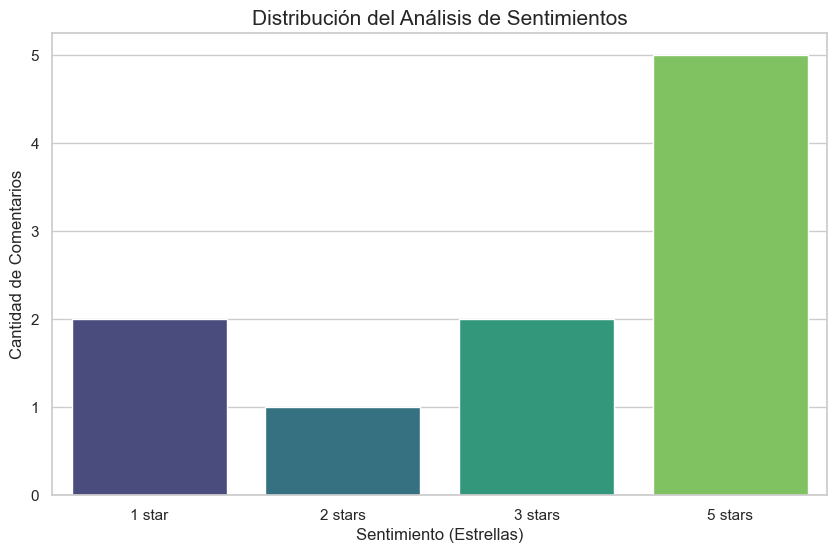

In [4]:
# Configuración visual de la gráfica
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Gráfica de barras de la distribución de sentimientos
ax = sns.countplot(data=df_resultados, x='label', order=sorted(df_resultados['label'].unique()), palette="viridis")
plt.title('Distribución del Análisis de Sentimientos', fontsize=15)
plt.xlabel('Sentimiento (Estrellas)', fontsize=12)
plt.ylabel('Cantidad de Comentarios', fontsize=12)
plt.show()

# Análisis de Datos Recabados
Analizando los sentimientos que más prevalecen en el conjunto de datos:

In [5]:
# Cálculo de estadísticas
prevalencia = df_resultados['label'].value_counts()
sentimiento_principal = prevalencia.idxmax()
porcentaje_principal = (prevalencia.max() / len(df_resultados)) * 100

print(f"El sentimiento predominante es: {sentimiento_principal}")
print(f"Representa el {porcentaje_principal}% de los comentarios analizados.")

# Análisis cualitativo
positivos = len(df_resultados[df_resultados['label'].isin(['4 stars', '5 stars'])])
negativos = len(df_resultados[df_resultados['label'].isin(['1 star', '2 stars'])])
neutrales = len(df_resultados[df_resultados['label'] == '3 stars'])

print(f"\nResumen General:")
print(f"- Comentarios Positivos: {positivos}")
print(f"- Comentarios Negativos: {negativos}")
print(f"- Comentarios Neutrales: {neutrales}")

El sentimiento predominante es: 5 stars
Representa el 50.0% de los comentarios analizados.

Resumen General:
- Comentarios Positivos: 5
- Comentarios Negativos: 3
- Comentarios Neutrales: 2
